<a href="https://colab.research.google.com/github/ayyanarh1/tamil-nadu-school-flood-risk/blob/main/day6_publication_maps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup
!pip install geopandas folium contextily matplotlib mapclassify netCDF4 -q

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import contextily as ctx
from shapely.geometry import Point

print('✅ Day 6 ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.5 MB/s eta 0:00:00
✅ Day 6 ready!


In [1]:
# Build GeoDataFrame with all risk data
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

# Complete school dataset with all risk scores
data = {
    'school_name': [
        'School Puducherry Border',
        'Panchayat School Nagapattinam',
        'School Ramanathapuram',
        'Govt School Cuddalore',
        'School Tuticorin',
        'School Kanchipuram',
        'Govt School Tiruchirappalli',
        'Panchayat School Tirunelveli',
        'Govt School Thanjavur',
        'High School Vellore',
        'School Villupuram',
        'Govt School Madurai',
        'Govt High School Chennai',
        'High School Coimbatore',
        'Govt School Salem'
    ],
    'latitude': [
        11.93, 10.76, 9.37, 11.75, 8.80,
        12.83, 10.79, 8.71, 10.78, 12.92,
        11.93, 9.93, 13.08, 11.01, 11.65
    ],
    'longitude': [
        79.83, 79.84, 78.83, 79.75, 78.15,
        79.70, 78.68, 77.69, 79.13, 79.13,
        79.49, 78.12, 80.27, 76.96, 78.16
    ],
    'connectivity': [
        'connected', 'none', 'none', 'none',
        'connected', 'none', 'none', 'none',
        'connected', 'connected', 'none',
        'connected', 'connected', 'connected', 'connected'
    ],
    'current_score': [
        96.7, 56.8, 43.5, 39.8, 39.1,
        33.3, 31.4, 30.7, 26.5, 22.1,
        22.9, 13.0, 13.8, 4.8, 4.9
    ],
    'current_risk': [
        'CRITICAL', 'CRITICAL', 'HIGH', 'HIGH', 'HIGH',
        'HIGH', 'HIGH', 'HIGH', 'HIGH', 'MEDIUM',
        'MEDIUM', 'MEDIUM', 'MEDIUM', 'LOW', 'LOW'
    ],
    'risk_ssp245': [
        'CRITICAL', 'CRITICAL', 'CRITICAL', 'HIGH', 'HIGH',
        'HIGH', 'HIGH', 'HIGH', 'HIGH', 'HIGH',
        'HIGH', 'MEDIUM', 'MEDIUM', 'LOW', 'LOW'
    ],
    'risk_ssp585': [
        'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL', 'CRITICAL',
        'HIGH', 'HIGH', 'HIGH', 'HIGH', 'HIGH',
        'HIGH', 'MEDIUM', 'MEDIUM', 'LOW', 'LOW'
    ],
    'score_ssp245': [
        100.0, 65.3, 50.0, 45.8, 45.0,
        38.3, 36.1, 35.3, 30.5, 25.4,
        26.3, 15.0, 15.9, 5.5, 5.6
    ],
    'score_ssp585': [
        100.0, 73.8, 56.6, 51.7, 50.8,
        43.3, 40.8, 39.9, 34.5, 28.7,
        29.8, 16.9, 17.9, 6.2, 6.4
    ]
}

df = pd.DataFrame(data)

# Convert to GeoDataFrame
geometry = [Point(lon, lat) for lat, lon
            in zip(df['latitude'], df['longitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

print(f'✅ GeoDataFrame created: {len(gdf)} schools')
print(f'CRS: {gdf.crs}')
print(gdf[['school_name', 'current_risk', 'risk_ssp585']].to_string(index=False))

✅ GeoDataFrame created: 15 schools
CRS: EPSG:4326
                  school_name current_risk risk_ssp585
     School Puducherry Border     CRITICAL    CRITICAL
Panchayat School Nagapattinam     CRITICAL    CRITICAL
        School Ramanathapuram         HIGH    CRITICAL
        Govt School Cuddalore         HIGH    CRITICAL
             School Tuticorin         HIGH    CRITICAL
           School Kanchipuram         HIGH        HIGH
  Govt School Tiruchirappalli         HIGH        HIGH
 Panchayat School Tirunelveli         HIGH        HIGH
        Govt School Thanjavur         HIGH        HIGH
          High School Vellore       MEDIUM        HIGH
            School Villupuram       MEDIUM        HIGH
          Govt School Madurai       MEDIUM      MEDIUM
     Govt High School Chennai       MEDIUM      MEDIUM
       High School Coimbatore          LOW         LOW
            Govt School Salem          LOW         LOW


In [3]:
# nstall contextily
!pip install contextily -q
import contextily as ctx
print('✅ contextily installed!')

✅ contextily installed!


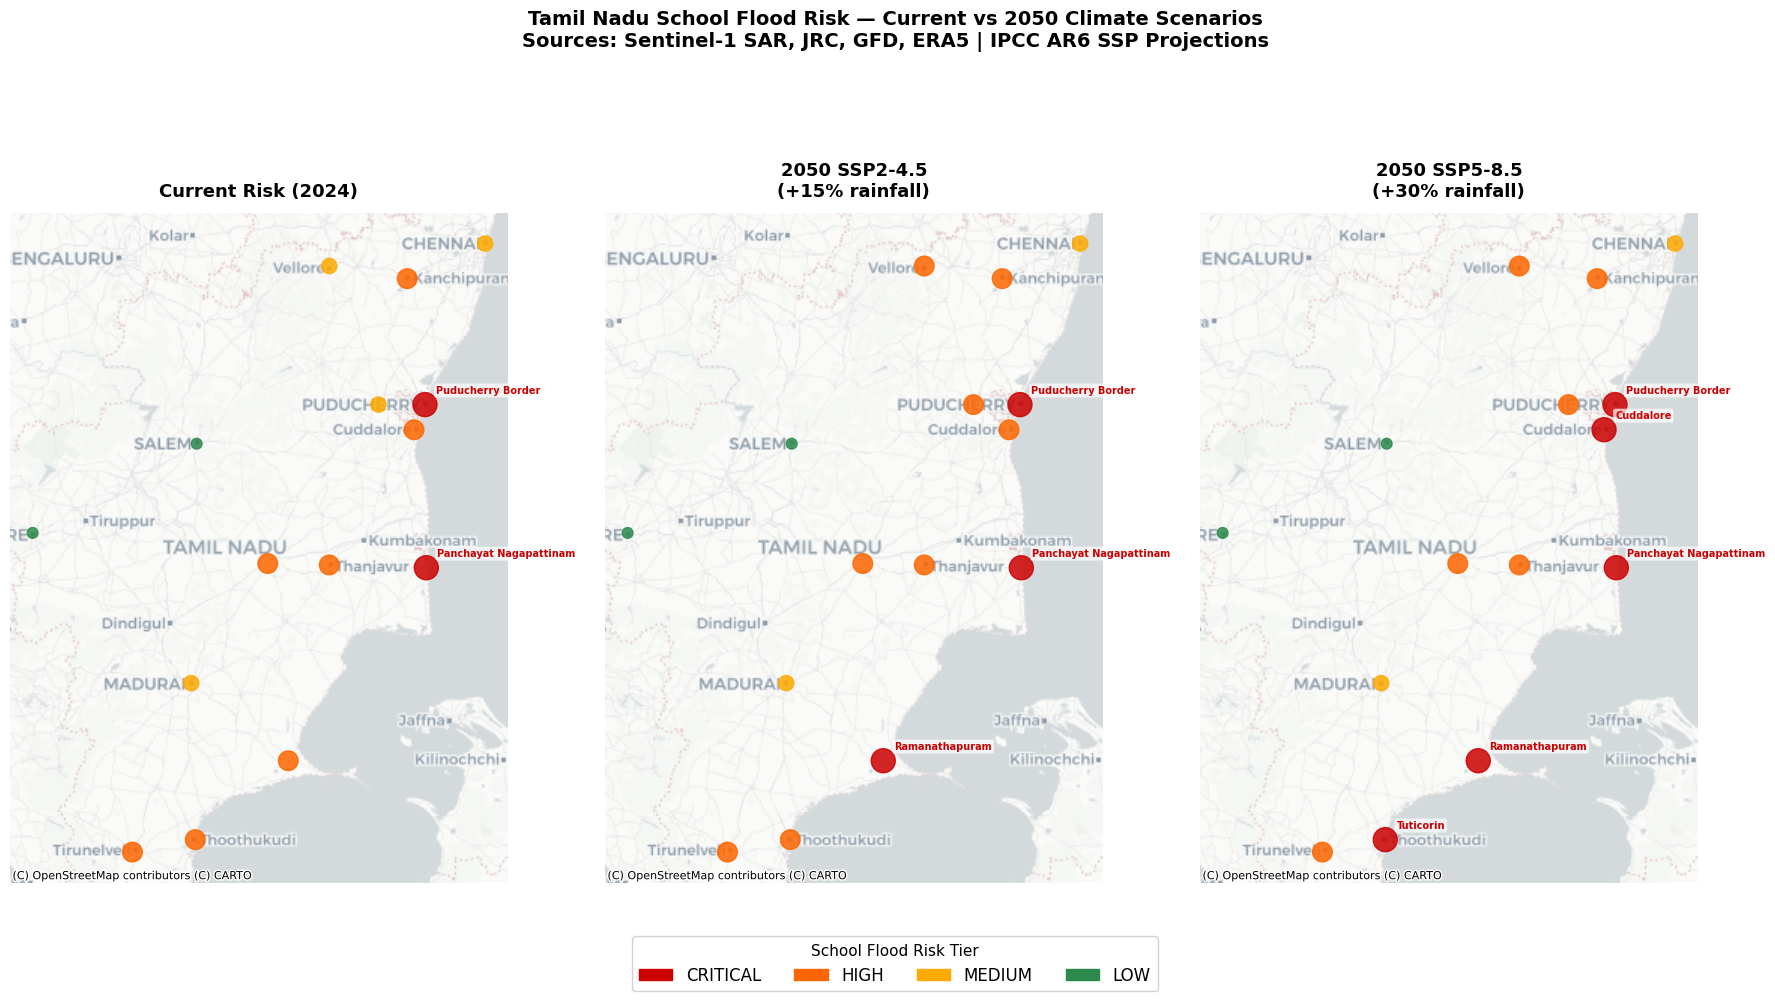

✅ Publication map saved at 300 DPI!


In [4]:
# panel publication quality map
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import geopandas as gpd

# Reproject to Web Mercator for contextily basemap
gdf_web = gdf.to_crs(epsg=3857)

# Risk colors
risk_colors = {
    'CRITICAL': '#cc0000',
    'HIGH':     '#ff6600',
    'MEDIUM':   '#ffaa00',
    'LOW':      '#2d8a4e'
}

# Risk to size
risk_sizes = {
    'CRITICAL': 300,
    'HIGH':     200,
    'MEDIUM':   120,
    'LOW':      60
}

# Three scenarios
scenarios = [
    ('current_risk',  'Current Risk (2024)'),
    ('risk_ssp245',   '2050 SSP2-4.5\n(+15% rainfall)'),
    ('risk_ssp585',   '2050 SSP5-8.5\n(+30% rainfall)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 10))

for ax, (risk_col, title) in zip(axes, scenarios):
    # Color and size per school
    colors = [risk_colors[r] for r in gdf_web[risk_col]]
    sizes  = [risk_sizes[r]  for r in gdf_web[risk_col]]

    # Plot school points
    gdf_web.plot(
        ax=ax,
        color=colors,
        markersize=sizes,
        alpha=0.85,
        zorder=3
    )

    # Add basemap
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.Positron,
        zoom=7
    )

    # Add school name labels for CRITICAL schools only
    for _, row in gdf_web.iterrows():
        if row[risk_col] == 'CRITICAL':
            ax.annotate(
                row['school_name'].replace('School ', '').replace('Govt ', ''),
                xy=(row.geometry.x, row.geometry.y),
                xytext=(8, 8),
                textcoords='offset points',
                fontsize=7,
                color='#cc0000',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2',
                         facecolor='white',
                         alpha=0.7,
                         edgecolor='none')
            )

    # Title and formatting
    ax.set_title(title, fontsize=13,
                fontweight='bold', pad=12)
    ax.set_axis_off()

# Legend
legend_patches = [
    mpatches.Patch(color='#cc0000', label='CRITICAL'),
    mpatches.Patch(color='#ff6600', label='HIGH'),
    mpatches.Patch(color='#ffaa00', label='MEDIUM'),
    mpatches.Patch(color='#2d8a4e', label='LOW'),
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=4,
    fontsize=12,
    framealpha=0.9,
    bbox_to_anchor=(0.5, 0.02),
    title='School Flood Risk Tier',
    title_fontsize=11
)

# Main title
fig.suptitle(
    'Tamil Nadu School Flood Risk — Current vs 2050 Climate Scenarios\n'
    'Sources: Sentinel-1 SAR, JRC, GFD, ERA5 | IPCC AR6 SSP Projections',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig(
    'tamil_nadu_publication_map.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print('✅ Publication map saved at 300 DPI!')

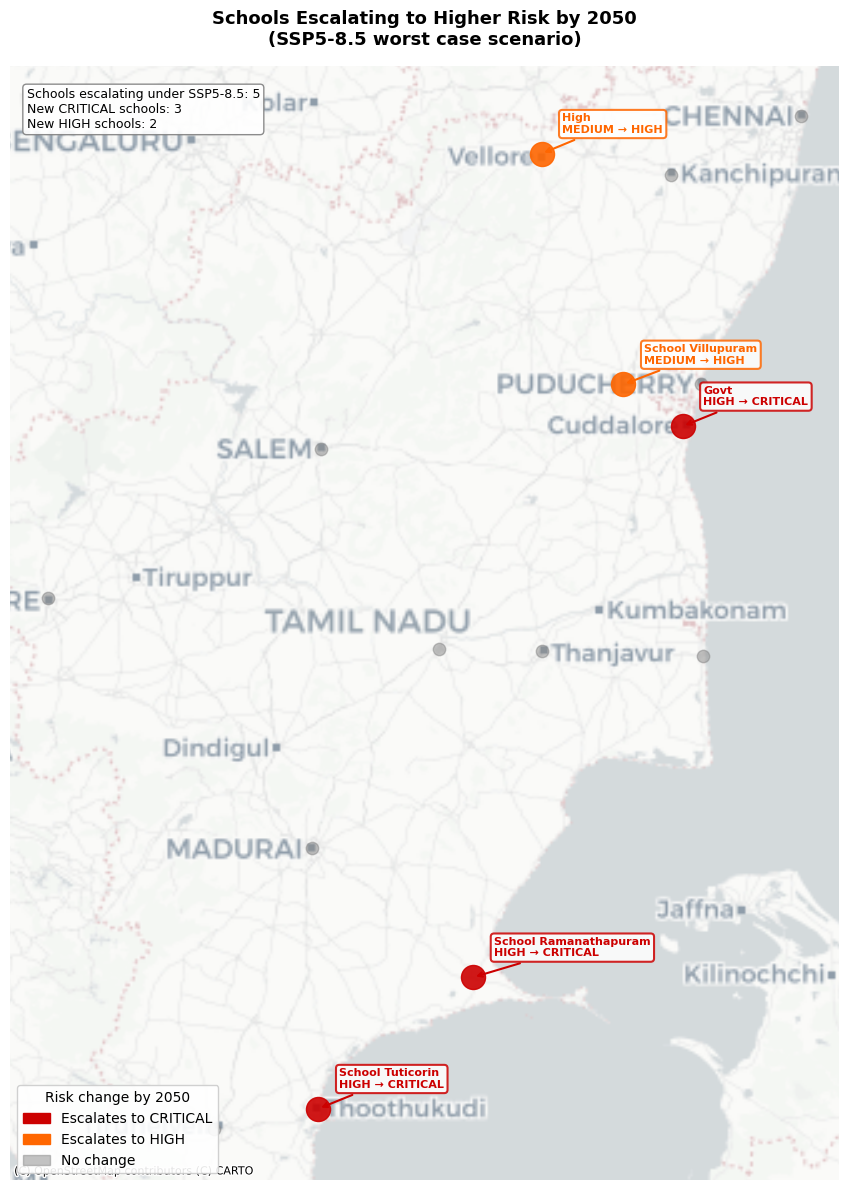

✅ Risk change map saved!


In [5]:
# Risk change map (schools that escalate by 2050)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx

# Identify schools that change risk tier
gdf_web['changes_ssp585'] = gdf_web['current_risk'] != gdf_web['risk_ssp585']
gdf_web['changes_ssp245'] = gdf_web['current_risk'] != gdf_web['risk_ssp245']

fig, ax = plt.subplots(figsize=(10, 12))

# Plot all schools — grey for no change
no_change = gdf_web[~gdf_web['changes_ssp585']]
no_change.plot(
    ax=ax,
    color='#888888',
    markersize=80,
    alpha=0.5,
    zorder=3,
    label='No change'
)

# Plot schools that escalate — colored by NEW risk tier
changes = gdf_web[gdf_web['changes_ssp585']]
for _, row in changes.iterrows():
    color = {
        'CRITICAL': '#cc0000',
        'HIGH':     '#ff6600',
        'MEDIUM':   '#ffaa00',
    }.get(row['risk_ssp585'], 'gray')

    ax.scatter(
        row.geometry.x,
        row.geometry.y,
        c=color,
        s=300,
        zorder=5,
        alpha=0.9
    )

    # Arrow showing escalation
    ax.annotate(
        f"{row['school_name'].split(' School')[0]}\n"
        f"{row['current_risk']} → {row['risk_ssp585']}",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(15, 15),
        textcoords='offset points',
        fontsize=8,
        fontweight='bold',
        color=color,
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            alpha=0.85,
            edgecolor=color,
            linewidth=1.5
        ),
        arrowprops=dict(
            arrowstyle='->',
            color=color,
            lw=1.5
        )
    )

# Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=7
)

ax.set_axis_off()
ax.set_title(
    'Schools Escalating to Higher Risk by 2050\n'
    '(SSP5-8.5 worst case scenario)',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Legend
legend_elements = [
    mpatches.Patch(color='#cc0000', label='Escalates to CRITICAL'),
    mpatches.Patch(color='#ff6600', label='Escalates to HIGH'),
    mpatches.Patch(color='#888888', label='No change', alpha=0.5),
]
ax.legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=10,
    framealpha=0.9,
    title='Risk change by 2050',
    title_fontsize=10
)

# Stats box
stats_text = (
    f"Schools escalating under SSP5-8.5: "
    f"{gdf_web['changes_ssp585'].sum()}\n"
    f"New CRITICAL schools: "
    f"{len(gdf_web[(gdf_web.changes_ssp585) & (gdf_web.risk_ssp585 == 'CRITICAL')])}\n"
    f"New HIGH schools: "
    f"{len(gdf_web[(gdf_web.changes_ssp585) & (gdf_web.risk_ssp585 == 'HIGH')])}"
)
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9,
        edgecolor='gray'
    )
)

plt.tight_layout()
plt.savefig(
    'tamil_nadu_risk_change_map.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
print('✅ Risk change map saved!')

In [7]:
# Download all Day 6 outputs
from google.colab import files

files.download('tamil_nadu_publication_map.png')
files.download('tamil_nadu_risk_change_map.png')
print('✅ All maps downloaded!')

# Summary
print()
print('=== DAY 6 SUMMARY ===')
print()
print('Maps created:')
print('  📍 3-panel scenario map (300 DPI)')
print('  📍 Risk change escalation map (300 DPI)')
print()
print('Schools escalating under SSP5-8.5:',
      gdf_web['changes_ssp585'].sum())
print('Schools escalating under SSP2-4.5:',
      gdf_web['changes_ssp245'].sum())
print()
print('These maps are ready for:')
print('  ✅ UNICEF reports')
print('  ✅ Academic papers')
print('  ✅ Interview presentations')
print('  ✅ PowerPoint deck')
print('  ✅ Public policy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All maps downloaded!

=== DAY 6 SUMMARY ===

Maps created:
  📍 3-panel scenario map (300 DPI)
  📍 Risk change escalation map (300 DPI)

Schools escalating under SSP5-8.5: 5
Schools escalating under SSP2-4.5: 3

These maps are ready for:
  ✅ UNICEF reports
  ✅ Academic papers
  ✅ Interview presentations
  ✅ PowerPoint deck
  ✅ Public policy
